#Análisis de datos de tiendas del sr. Juan para toma de decisiones

Dirigido a Juan X., CEO de la corporación Tiendas felices.

Por Ana Berenice Noriega Camacho.

##Introducción
Definir el rendimiento de las ventas en nuestras sedes es de alta relevancia para tomar decisiones estratégicas para el negocio. Como ha sido solicitado, a continuación se muestra un análisis exhaustivo del desempeño que ha tenido cada uno de nuestros puntos de venta, y mis recomendaciones al final del documento para la decisión sobre qué tienda conviene vender.



## Importación de datos

Estos son los archivos que nos ha compartido para realizar el análisis. Existe uno para cada una de las cuatro tiendas a cargo de la corporación.




In [57]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


##Conociendo los datos

Se exploraron las bases de datos para verificar que todo estuviera en orden y conocer la información que poseemos actualmente sobre cada tienda. La información más relevante para nosotros será la del precio, categoría, costo de envío y calificaciones de los productos.

In [58]:
tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [59]:
tienda1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


Todas las bases de datos tienen datos completos. Sin embargo, hay que tomar en cuenta que a comparación de las demás tiendas, la tienda 4 tiene un producto menos en la lista total.

#1. Ingreso total de cada tienda



Evaluamos el ingreso total de cada tienda para determinar cuál de ellas ha tenido mayor número de ventas.

**La tienda 1 ha tenido mayor número total de ventas**

La tienda 4 ha sido la de menor número de ventas.

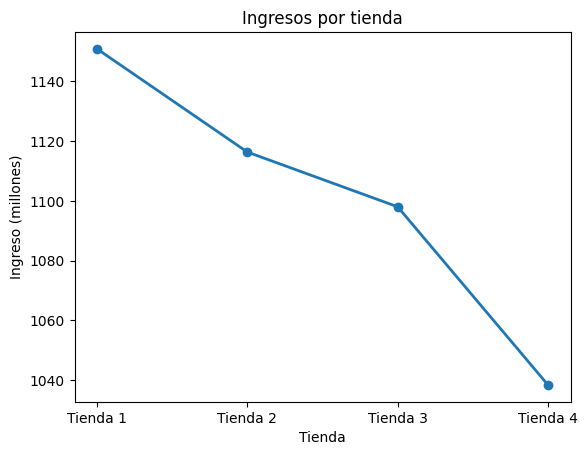

In [180]:
import matplotlib.pyplot as plt
ingresoTienda1 = tienda1['Precio'].sum()
ingresoTienda2 = tienda2['Precio'].sum()
ingresoTienda3 = tienda3['Precio'].sum()
ingresoTienda4 = tienda4['Precio'].sum()

ingreso_total = ingresoTienda1 + ingresoTienda2 + ingresoTienda3 + ingresoTienda4

resultado = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso': [ingresoTienda1, ingresoTienda2, ingresoTienda3, ingresoTienda4]})

resultado['Ingreso_millones'] = resultado['Ingreso'] / 1_000_000

plt.plot(
    resultado['Tienda'],
    resultado['Ingreso_millones'],
    marker='o',
    linewidth=2
)

plt.title('Ingresos por tienda')
plt.xlabel('Tienda')
plt.ylabel('Ingreso (millones)')

plt.show()




In [181]:
resultado


,Tienda,Ingreso,Ingreso_millones
0,Tienda 1,1.150880e+09,1150.8804
1,Tienda 2,1.116344e+09,1116.3435
2,Tienda 3,1.098020e+09,1098.0196
3,Tienda 4,1.038376e+09,1038.3757


# 2. Ventas por categoría

**La categoría que más ventas tuvo en todas las tiendas fue la de electrónicos.**

La categoría de menos ventas fue libros.

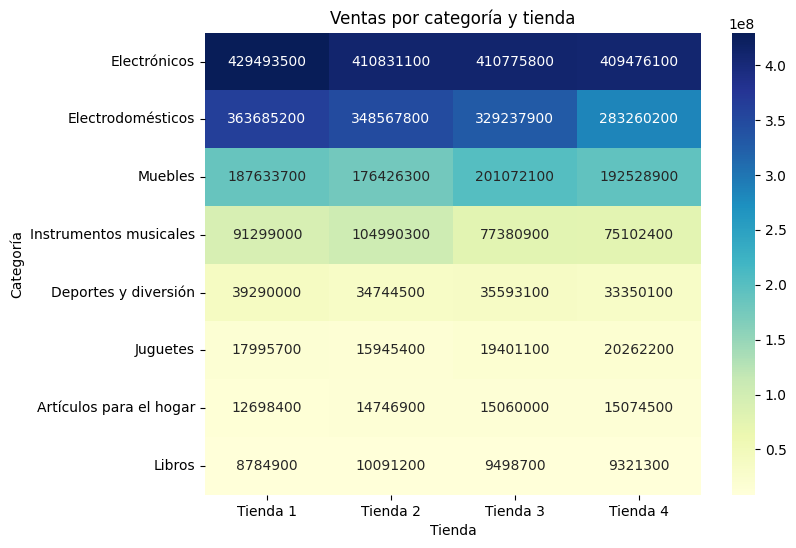

In [175]:
ventasxcategoria_tienda1=tienda1.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventasxcategoria_tienda2=tienda2.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventasxcategoria_tienda3=tienda3.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventasxcategoria_tienda4=tienda4.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)

categoriasxtienda = [
    ventasxcategoria_tienda1,
    ventasxcategoria_tienda2,
    ventasxcategoria_tienda3,
    ventasxcategoria_tienda4
]

ventas_total = pd.concat(
    categoriasxtienda,
    axis=1
)

ventas_total.columns = ['Tienda 1','Tienda 2','Tienda 3','Tienda 4']
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    ventas_total,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar=True
)

plt.title('Ventas por categoría y tienda')
plt.xlabel('Tienda')
plt.ylabel('Categoría')
plt.show()


# 3. Calificación promedio de la tienda

**La Tienda 3 es la de mejor calificación, con un promedio de 4.04**

La Tienda 1 es la peor calificada, con 3.97

In [99]:
calificacion_tienda1 = tienda1['Calificación'].mean()
calificacion_tienda2 = tienda2['Calificación'].mean()
calificacion_tienda3 = tienda3['Calificación'].mean()
calificacion_tienda4 = tienda4['Calificación'].mean()

calificaciones = pd.DataFrame({
    'Tienda': ['Tienda1', 'Tienda2', 'Tienda3', 'Tienda4'],
    'Calificación': [calificacion_tienda1, calificacion_tienda2, calificacion_tienda3, calificacion_tienda4]
})

calificaciones = calificaciones.sort_values(
    by='Calificación',
    ascending=False
)

calificaciones = calificaciones.style.hide(axis='index')
calificaciones

Tienda,Calificación
Tienda3,4.048326
Tienda2,4.037304
Tienda4,3.995759
Tienda1,3.976685


# 4. Productos más y menos vendidos

En la gráfica se muestra el top 3 de productos mejores y peores vendidos de cada tienda. Los resultados son bastante variables entre tiendas, no hay productos que sea predominantemente más vendidos en todas.

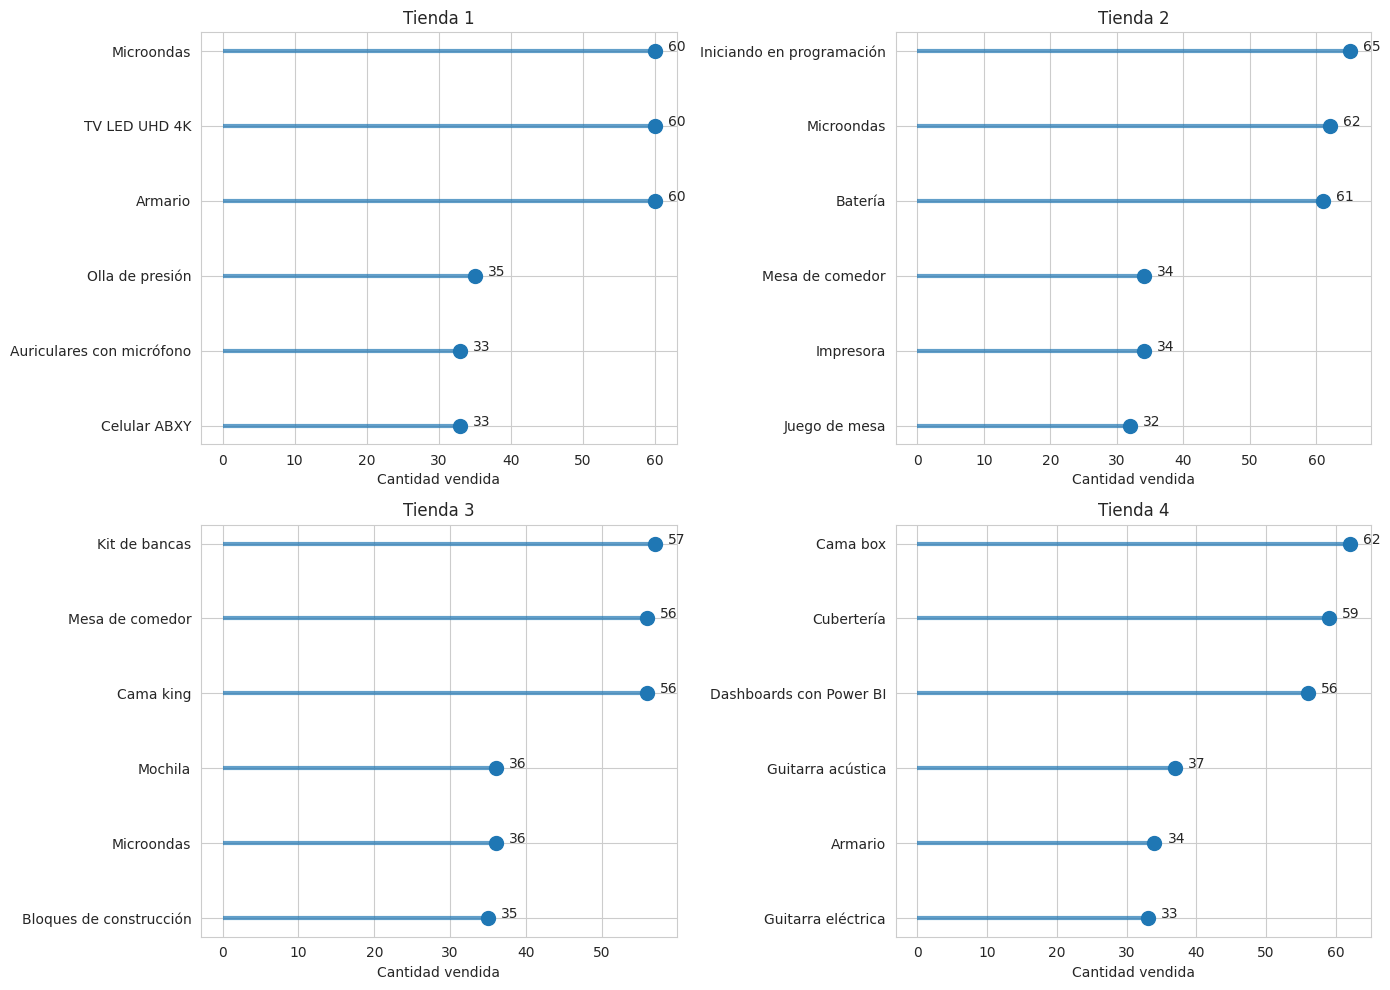

In [195]:
#Top 3 de productos más vendidos por tienda
top3_tienda1=tienda1['Producto'].value_counts().head(3)
top3_tienda2=tienda2['Producto'].value_counts().head(3)
top3_tienda3=tienda3['Producto'].value_counts().head(3)
top3_tienda4=tienda4['Producto'].value_counts().head(3)

#Los 3 productos menos vendidos por tienda
worst3_tienda1=tienda1['Producto'].value_counts().tail(3)
worst3_tienda2=tienda2['Producto'].value_counts().tail(3)
worst3_tienda3=tienda3['Producto'].value_counts().tail(3)
worst3_tienda4=tienda4['Producto'].value_counts().tail(3)

tiendas = {
    'Tienda 1': (top3_tienda1, worst3_tienda1),
    'Tienda 2': (top3_tienda2, worst3_tienda2),
    'Tienda 3': (top3_tienda3, worst3_tienda3),
    'Tienda 4': (top3_tienda4, worst3_tienda4)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (tienda, (top3, worst3)) in enumerate(tiendas.items()):
    ax = axes[i]

    productos = list(top3.index) + list(worst3.index)
    valores = list(top3.values) + list(worst3.values)

    y_pos = range(len(productos))

    ax.hlines(y=y_pos, xmin=0, xmax=valores, alpha=0.7, linewidth=3)
    ax.plot(valores, y_pos, "o", markersize=10)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(productos)

    ax.set_xlabel("Cantidad vendida")
    ax.set_title(tienda)

    ax.invert_yaxis()

    for j, v in enumerate(valores):
        ax.text(v + max(valores)*0.03, j, str(v), fontsize=10)

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda
**La Tienda 4 tiene costos mucho menores de envío.**

La Tienda 1 es la que tiene mayores costos de envío.

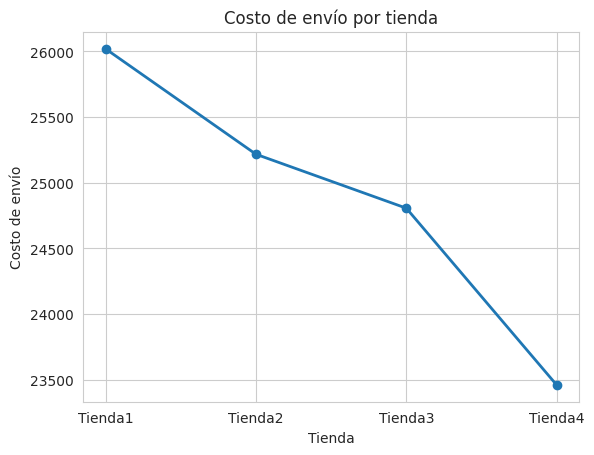

In [197]:
envio_tienda1= tienda1['Costo de envío'].mean()
envio_tienda2= tienda2['Costo de envío'].mean()
envio_tienda3= tienda3['Costo de envío'].mean()
envio_tienda4= tienda4['Costo de envío'].mean()

df_costosenvio=pd.DataFrame({"Tienda":["Tienda1","Tienda2","Tienda3","Tienda4"],
              "Costo de envío": [envio_tienda1,envio_tienda2,envio_tienda3,envio_tienda4]})

plt.plot(
    df_costosenvio['Tienda'],
    df_costosenvio['Costo de envío'],
    marker='o',
    linewidth=2
)

plt.title('Costo de envío por tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de envío')

plt.show()


#Conclusiones sobre las tiendas

**La Tienda con mayores ventas es la Tienda 1.**

A pesar de su baja calificación y sus altos costos de envío, la tienda 1 tiene significativamente mayores ventas que todas las demás.

Recomendaría optimizar y mejorar el servicio en esta sucursal para explotar aún más su potencial en ventas que los datos ya muestran.

**La tienda que recomendaría vender es la Tienda 4.**

Siendo la tienda con menores ventas, y la segunda con peores calificaciones, y cuya única ventaja en los datos parece ser el menor coste en el envío, se posiciona como la primera recomendación de venta en caso de considerarse mejor y necesario para la empresa.

#Conclusiones sobre los productos

**Los electrónicos son nuestra categoría estrella.**
Recomiendo que se invierta en promoción y stock de productos de esta categoría. Es necesario también invertir en estrategias de venta para los Libros, que resulta ser la categoría menos vendida en todas las tiendas.

Por último, los productos más y menos populares varían entre todas las tiendas, por lo que recomiendo hacer un registro longitudinal en cada tienda para conocer cuáles son los favoritos de los clientes en cada espacio.



*Este fue un ejercicio realizado como parte del Alura Store Challenge del programa Oracle Next Education en colaboración con Alura LATAM.*